In [1]:
# ── Cell 1 — Imports ─────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models, callbacks

print("TF version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

TF version: 2.20.0


In [2]:
# ── Cell 2 — CONFIG (change TAG to switch between files) ─────────────────────
TAG         = "Fri_DDoS"          # ← train once on "Fri_DDoS" and "Fri_Morning" files
PROCESSED   = "../../data/processed"
MODELS_DIR  = "../../files/models_name"
EDA_DIR     = "../../notebooks/eda_outputs"

os.makedirs(MODELS_DIR, exist_ok=True)

DATA_PATH   = os.path.join(PROCESSED, f"{TAG}.csv")
TARGET_COL  = "Label"
LABEL_ENC   = "label_enc"
BATCH_SIZE  = 512
EPOCHS      = 30

In [3]:
# ── Cell 3 — Load data + canonical features ───────────────────────────────────
with open(f"{EDA_DIR}/08_canonical_features.json") as f:
    canonical_list = json.load(f)

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"[{TAG}] Loaded: {len(df):,} rows")
print(f"Classes: {df[TARGET_COL].unique().tolist()}")

for col in canonical_list:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=[LABEL_ENC])

feat_cols = [f for f in canonical_list if f in df.columns]
X = df[feat_cols].values.astype(np.float32)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"X shape: {X.shape} | Feature count: {len(feat_cols)}")

[Fri_DDoS] Loaded: 239,416 rows
Classes: ['BENIGN', 'DDoS']
X shape: (239416, 84) | Feature count: 84


In [4]:
# ── Cell 4 — Use LOCAL label encoder for this file ───────────────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL].values)

NUM_CLASSES = len(le.classes_)
print(f"Classes in this file: {le.classes_}")
print(f"Num classes: {NUM_CLASSES}")

Classes in this file: ['BENIGN' 'DDoS']
Num classes: 2


In [5]:
# ── Cell 4b — Scale features ──────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X = scaler.fit_transform(X)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Save scaler — needed at inference time
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))
print("✅ Scaler fitted and saved")
print(f"X mean: {X.mean():.4f} | X std: {X.std():.4f}")  # should be ~0 and ~1

✅ Scaler fitted and saved
X mean: -0.0000 | X std: 0.9820


In [6]:
# ── Cell 5 — Train/Val/Test split ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

# Reshape for Conv1D: (samples, timesteps, channels)
X_train = X_train.reshape(-1, X_train.shape[1], 1)
X_val   = X_val.reshape(-1, X_val.shape[1], 1)
X_test  = X_test.reshape(-1, X_test.shape[1], 1)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (172977, 84, 1) | Val: (30526, 84, 1) | Test: (35913, 84, 1)


In [7]:
print("Class distribution in full df:")
print(df[TARGET_COL].value_counts())

print("\nLabel encoder classes:")
print(le.classes_)

print("\ny unique values:", np.unique(y_train))

Class distribution in full df:
Label
BENIGN    144272
DDoS       95144
Name: count, dtype: int64

Label encoder classes:
['BENIGN' 'DDoS']

y unique values: [0 1]


In [8]:
# ── Cell 6 — Build CNN ────────────────────────────────────────────────────────
def build_cnn(input_len, num_classes):
    inp = layers.Input(shape=(input_len, 1))
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(inp)
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out)

cnn = build_cnn(X_train.shape[1], NUM_CLASSES)
cnn.summary()

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 84, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 84, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 84, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,498 (228.51 KB)

 Trainable params: 58,498 (228.51 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ── Cell 7 — Train ────────────────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=3,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=2, verbose=1)
]

history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    verbose=1
)


Epoch 1/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.9774 - loss: 0.0535 - val_accuracy: 0.9998 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 2/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.9998 - loss: 0.0016 - val_accuracy: 0.9998 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 3/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9997 - loss: 0.0030 - val_accuracy: 0.9998 - val_loss: 9.5339e-04 - learning_rate: 0.0010
Epoch 4/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.9999 - loss: 8.2219e-04 - val_accuracy: 0.9998 - val_loss: 4.2781e-04 - learning_rate: 0.0010
Epoch 5/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.9998 - loss: 0.0020 - val_accuracy: 0.9998 - val_loss: 3.4501e-04 - learning_rate: 0.0010
Epoch 6/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9999 - loss: 3.3452e-04
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
338/338 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - ac

In [10]:
# ── Cell 8 — Evaluate ─────────────────────────────────────────────────────────
loss, acc = cnn.evaluate(X_test, y_test, verbose=0)
print(f"\n[{TAG}] Test Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")


[Fri_DDoS] Test Accuracy: 99.99%  |  Loss: 0.0003


In [13]:
# ── Cell 8b — Overfitting Check ───────────────────────────────────────────────
train_loss, train_acc = cnn.evaluate(X_train, y_train, verbose=0)
val_loss,   val_acc   = cnn.evaluate(X_val,   y_val,   verbose=0)
test_loss,  test_acc  = cnn.evaluate(X_test,  y_test,  verbose=0)

print(f"Train Accuracy : {train_acc*100:.2f}%  |  Loss: {train_loss:.4f}")
print(f"Val   Accuracy : {val_acc*100:.2f}%  |  Loss: {val_loss:.4f}")
print(f"Test  Accuracy : {test_acc*100:.2f}%  |  Loss: {test_loss:.4f}")

gap = train_acc - test_acc
print(f"\nTrain-Test Accuracy Gap: {gap*100:.2f}%")

if gap > 0.05:
    print("⚠️  Overfit — gap > 5%")
elif gap > 0.02:
    print("⚠️  Mild overfit — gap 2-5%")
else:
    print("✅ No significant overfit")

Train Accuracy : 100.00%  |  Loss: 0.0001
Val   Accuracy : 99.99%  |  Loss: 0.0002
Test  Accuracy : 99.99%  |  Loss: 0.0003

Train-Test Accuracy Gap: 0.00%
✅ No significant overfit


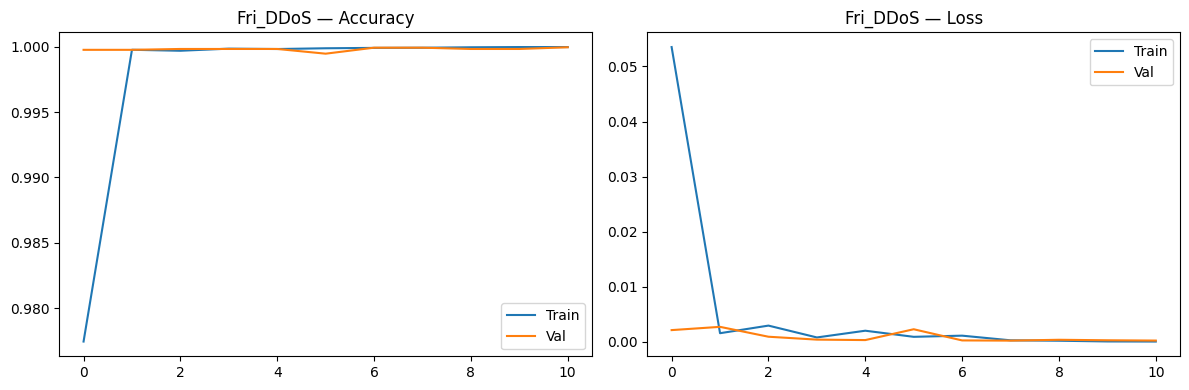

In [11]:
# ── Cell 9 — Plot ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title(f'{TAG} — Accuracy'); ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title(f'{TAG} — Loss'); ax2.legend()

plt.tight_layout()
plt.savefig(f"{EDA_DIR}/{TAG}_cnn_training.png", dpi=100)
plt.show()

In [12]:
# ── Cell 10 — Save model ──────────────────────────────────────────────────────
save_path = os.path.join(MODELS_DIR, "cnn_model.h5")
cnn.save(save_path)
print(f"✅ Saved: {save_path}")

✅ Saved: ../../files/models_name\cnn_model.h5


# 